# Applied Optimization — Before/After Pipeline Benchmark [ex133.3]

Measures the effect of the F-order + in-place optimization on the **full `RLSAlssm.filter()` pipeline**
rather than the cascade kernel in isolation.

Two changes were applied to the production code:

1. **`rec_lfilter.py`** — Forward and backward cascade write directly into `xi` (in-place).  
   The `xi0 = np.zeros_like(xi)` scratch buffer and the `xi += xi0` accumulation copy are gone.
2. **`rls.py`** — `_nd_xi_q_recursion` allocates a per-segment `_xi_seg` (F-order) and  
   accumulates `xi_curr += _xi_seg`, guaranteeing zero-on-entry to the backend.

The benchmark uses `RLSAlssm.filter()` with FW + BW segments, N=2, sweeping signal length K.
A monkey-patch strategy runs the "before" variant first, restores the original code, then runs "after" —
all in the same kernel session for a fair warm-memory comparison.

> **Cascade variant analysis**: **[ex133.1](example-ex133.1-cascade-variants.ipynb)**.
> Why memory appears unchanged at pipeline level is explained after the benchmark.


## Benchmark setup

`bench_filter(K)` runs `rls.filter(y)` with FW + BW segments and `backend='lfilter'`, performing
a warm-up call before timing. Returns median/min/max wall time and median tracemalloc peak.

In [19]:
import numpy as np
import tracemalloc, time
import lmlib as lm

# ---------- benchmark helper (shared by before and after variants) ----------
def bench_filter(K, reps_time=20, reps_mem=5):
    rng = np.random.default_rng(0)
    y   = rng.standard_normal(K)

    alssm  = lm.AlssmPoly(poly_degree=1)
    seg_fw = lm.Segment(a=-np.inf, b=-1, direction=lm.FW, g=100)
    seg_bw = lm.Segment(a=0,       b=np.inf, direction=lm.BW, g=100)
    cs  = lm.CompositeCost((alssm,), (seg_fw, seg_bw), F=[[1, 1]])
    rls = lm.RLSAlssm(cs, backend='lfilter')

    rls.filter(y)   # warm-up

    times = []
    for _ in range(reps_time):
        t0 = time.perf_counter()
        rls.filter(y)
        times.append((time.perf_counter() - t0) * 1e3)

    mems = []
    for _ in range(reps_mem):
        tracemalloc.start()
        rls.filter(y)
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        mems.append(peak / 1e6)

    return np.median(times), np.min(times), np.max(times), np.median(mems)

Ks_bench = [10_000, 100_000, 1_000_000]

## Before / after: same kernel, monkey-patched

The "before" implementations are exact replicas of the pre-optimization code.
They are monkey-patched into the live module, run first, then the originals are restored.
Both see the same warm-memory state, making the comparison self-consistent.

In [20]:
import lmlib.statespace.backends.rec_lfilter as _rlf
from lmlib.statespace.backends.rec import xi_q_recursion as _xi_q_recursion
from numpy.linalg import inv as _inv, matrix_power as _mpow
from scipy.signal import lfilter as _lfilter

# ══════════════════════════════════════════════════════════════════════════════
# "BEFORE" implementations (identical to the pre-optimization code)
# ══════════════════════════════════════════════════════════════════════════════

def _forward_before(xi, A, C, a, b, delta, gamma, y, v, beta):
    gamma_inv = 1 / gamma
    gamma_a   = gamma ** (a - 1 - delta)
    gamma_b   = gamma ** (b - delta)
    A_inv = _inv(A);  gAinvT = gamma_inv * A_inv.T
    Aa    = _mpow(A, 0 if np.isinf(a) else a - 1);  Aac = np.dot(Aa.T, C.T)
    Ab    = _mpow(A, b);                              Abc = np.dot(Ab.T, C.T)
    N     = np.shape(A)[1]
    vy    = y * v[:, None]
    y_delayed_b = np.empty_like(vy)
    y_delayed_b[:-b] = 0;  y_delayed_b[-b:] = vy[:b]
    y_diff = np.einsum('kl,nl->kn', y_delayed_b, gamma_b * Abc)
    if not np.isinf(a):
        y_delayed_a = np.empty_like(vy)
        y_delayed_a[:-a + 1] = 0;  y_delayed_a[-a + 1:] = vy[:a - 1]
        y_diff -= np.einsum('kl,nl->kn', y_delayed_a, gamma_a * Aac)
    y_diff = np.swapaxes(y_diff, 0, 1)
    xi0 = np.zeros(xi.shape, order='C')            # ← C-order scratch (original)
    xi0[:, 0] = _lfilter([1, 0], [1, -gamma_inv], y_diff[0].T).T
    for n_ in range(1, N):
        y_diff[n_, 1:] += np.einsum('kn...,n->k...', xi0[:-1], gAinvT[n_])
        xi0[:, n_] = _lfilter([1, 0], [1, -gamma_inv], y_diff[n_].T).T
    xi += xi0                                       # ← accumulation copy
    if beta != 1:
        xi *= beta


def _backward_before(xi, A, C, a, b, delta, gamma, y, v, beta):
    gamma_a = gamma ** (a - delta)
    gamma_b = gamma ** (b - delta + 1)
    gAT = gamma * A.T
    Aa  = _mpow(A, a);                               Aac = np.dot(Aa.T, C.T)
    Ab  = _mpow(A, 0 if np.isinf(b) else b + 1);    Abc = np.dot(Ab.T, C.T)
    N   = np.shape(A)[1]
    K   = len(xi)
    vy  = y * v[:, None]
    y_delayed_a = np.empty_like(vy)
    y_delayed_a[-a:] = 0;  y_delayed_a[:K - a] = vy[a:]
    y_diff = np.einsum('kl,nl->kn', y_delayed_a, gamma_a * Aac)
    if not np.isinf(b):
        y_delayed_b = np.empty_like(vy)
        y_delayed_b[-b - 1:] = 0;  y_delayed_b[:K - b - 1] = vy[b + 1:]
        y_diff -= np.einsum('kl,nl->kn', y_delayed_b, gamma_b * Abc)
    y_diff_flipped = np.swapaxes(y_diff[::-1], 0, 1)
    xi0 = np.zeros(xi.shape, order='C')            # ← C-order scratch (original)
    xi0[:, 0] = _lfilter([1, 0], [1, -gamma], y_diff_flipped[0].T).T
    for n_ in range(1, N):
        y_diff_flipped[n_, 1:] += np.einsum('kn...,n->k...', xi0[:-1], gAT[n_])
        xi0[:, n_] = _lfilter([1, 0], [1, -gamma], y_diff_flipped[n_].T).T
    xi += xi0[::-1]                                 # ← accumulation copy
    if beta != 1:
        xi *= beta


def _nd_xi_q_recursion_before(self, q, y, sample_weights, model_dimension):
    """Original rls.py: C-order xi_curr, shared across all cost segments."""
    sub_cost = self._cost_terms._get_sub_cost_term(model_dimension)
    N = sub_cost.get_alssm_order()
    *Ks, Q = np.shape(y)
    xi_curr = np.zeros((*Ks, N ** q,))             # ← C-order (no order='F')
    _xi_curr = np.moveaxis(xi_curr, model_dimension, -2)
    _xi_curr = np.reshape(_xi_curr, (-1, *_xi_curr.shape[-2:]))
    _y = np.moveaxis(y, model_dimension, -2)
    _y = np.reshape(_y, (-1, *_y.shape[-2:]))
    _sample_weights = np.moveaxis(sample_weights, model_dimension, -1)
    _sample_weights = np.reshape(_sample_weights, (-1, *_sample_weights.shape[-1:]))
    for cs in sub_cost._get_cost_segments(force_MC=True):
        for i in range(_y.shape[0]):
            _xi_q_recursion(_xi_curr[i], q,
                            cs.alssm, cs.segment,
                            _y[i], _sample_weights[i],
                            cs.beta, self._backend, self._filter_form)
    return xi_curr


# ══════════════════════════════════════════════════════════════════════════════
# Patch helpers + interleaved benchmark
# ══════════════════════════════════════════════════════════════════════════════
_orig_fw = _rlf.lfilter_forward_cascade_xi
_orig_bw = _rlf.lfilter_backward_cascade_xi
_orig_nd = lm.RLSAlssm._nd_xi_q_recursion

def _patch_before():
    _rlf.lfilter_forward_cascade_xi  = _forward_before
    _rlf.lfilter_backward_cascade_xi = _backward_before
    lm.RLSAlssm._nd_xi_q_recursion   = _nd_xi_q_recursion_before

def _patch_after():
    _rlf.lfilter_forward_cascade_xi  = _orig_fw
    _rlf.lfilter_backward_cascade_xi = _orig_bw
    lm.RLSAlssm._nd_xi_q_recursion   = _orig_nd

def _make_rls_bench():
    alssm  = lm.AlssmPoly(poly_degree=1)
    seg_fw = lm.Segment(a=-np.inf, b=-1, direction=lm.FW, g=100)
    seg_bw = lm.Segment(a=0,       b=np.inf, direction=lm.BW, g=100)
    cs = lm.CompositeCost((alssm,), (seg_fw, seg_bw), F=[[1, 1]])
    return lm.RLSAlssm(cs, backend='lfilter')

N_time, N_mem = 40, 10

results = {}
for K in Ks_bench:
    rng = np.random.default_rng(0)
    y   = rng.standard_normal(K)
    rls = _make_rls_bench()

    # Warm up both variants so neither starts cold
    _patch_before(); rls.filter(y)
    _patch_after();  rls.filter(y)

    # Interleaved timing: B₁ → A₁ → B₂ → A₂ → …
    # Both variants see the same system-load distribution across all repetitions.
    times_b, times_a = [], []
    for _ in range(N_time):
        _patch_before()
        t0 = time.perf_counter(); rls.filter(y); times_b.append((time.perf_counter() - t0) * 1e3)
        _patch_after()
        t0 = time.perf_counter(); rls.filter(y); times_a.append((time.perf_counter() - t0) * 1e3)

    mems_b, mems_a = [], []
    for _ in range(N_mem):
        _patch_before()
        tracemalloc.start(); rls.filter(y); _, p = tracemalloc.get_traced_memory(); tracemalloc.stop()
        mems_b.append(p / 1e6)
        _patch_after()
        tracemalloc.start(); rls.filter(y); _, p = tracemalloc.get_traced_memory(); tracemalloc.stop()
        mems_a.append(p / 1e6)

    _patch_after()  # always leave module in clean state
    results[K] = dict(tb=np.array(times_b), ta=np.array(times_a),
                      mb=np.array(mems_b),  ma=np.array(mems_a))

    mb  = np.median(times_b);  q1b, q3b = np.percentile(times_b, [25, 75])
    ma  = np.median(times_a);  q1a, q3a = np.percentile(times_a, [25, 75])
    pct = (ma - mb) / mb * 100
    print(f"K={K:>9,}  before {mb:6.2f} ms [Q1={q1b:.2f}, Q3={q3b:.2f}]  "
          f"after {ma:6.2f} ms [Q1={q1a:.2f}, Q3={q3a:.2f}]  {pct:+.1f}%")


K=   10,000  before   4.23 ms [Q1=4.21, Q3=4.25]  after   4.45 ms [Q1=4.41, Q3=4.47]  +5.2%
K=  100,000  before  12.47 ms [Q1=12.42, Q3=12.53]  after  11.35 ms [Q1=11.30, Q3=11.41]  -9.0%
K=1,000,000  before 107.68 ms [Q1=107.55, Q3=107.83]  after  91.92 ms [Q1=91.84, Q3=92.04]  -14.6%


           K        before ms  [Q1, Q3]        after ms  [Q1, Q3]    Δ time   before MB   after MB     Δ mem
--------------------------------------------------------------------------------------------------------------
      10,000    4.23  [4.21, 4.25]         4.45  [4.41, 4.47]      +5.2%         0.7        0.7     +0.1%
     100,000   12.47  [12.42, 12.53]        11.35  [11.30, 11.41]      -9.0%         7.2        7.2     +0.0%
   1,000,000  107.68  [107.55, 107.83]        91.92  [91.84, 92.04]     -14.6%        72.0       72.0     +0.0%


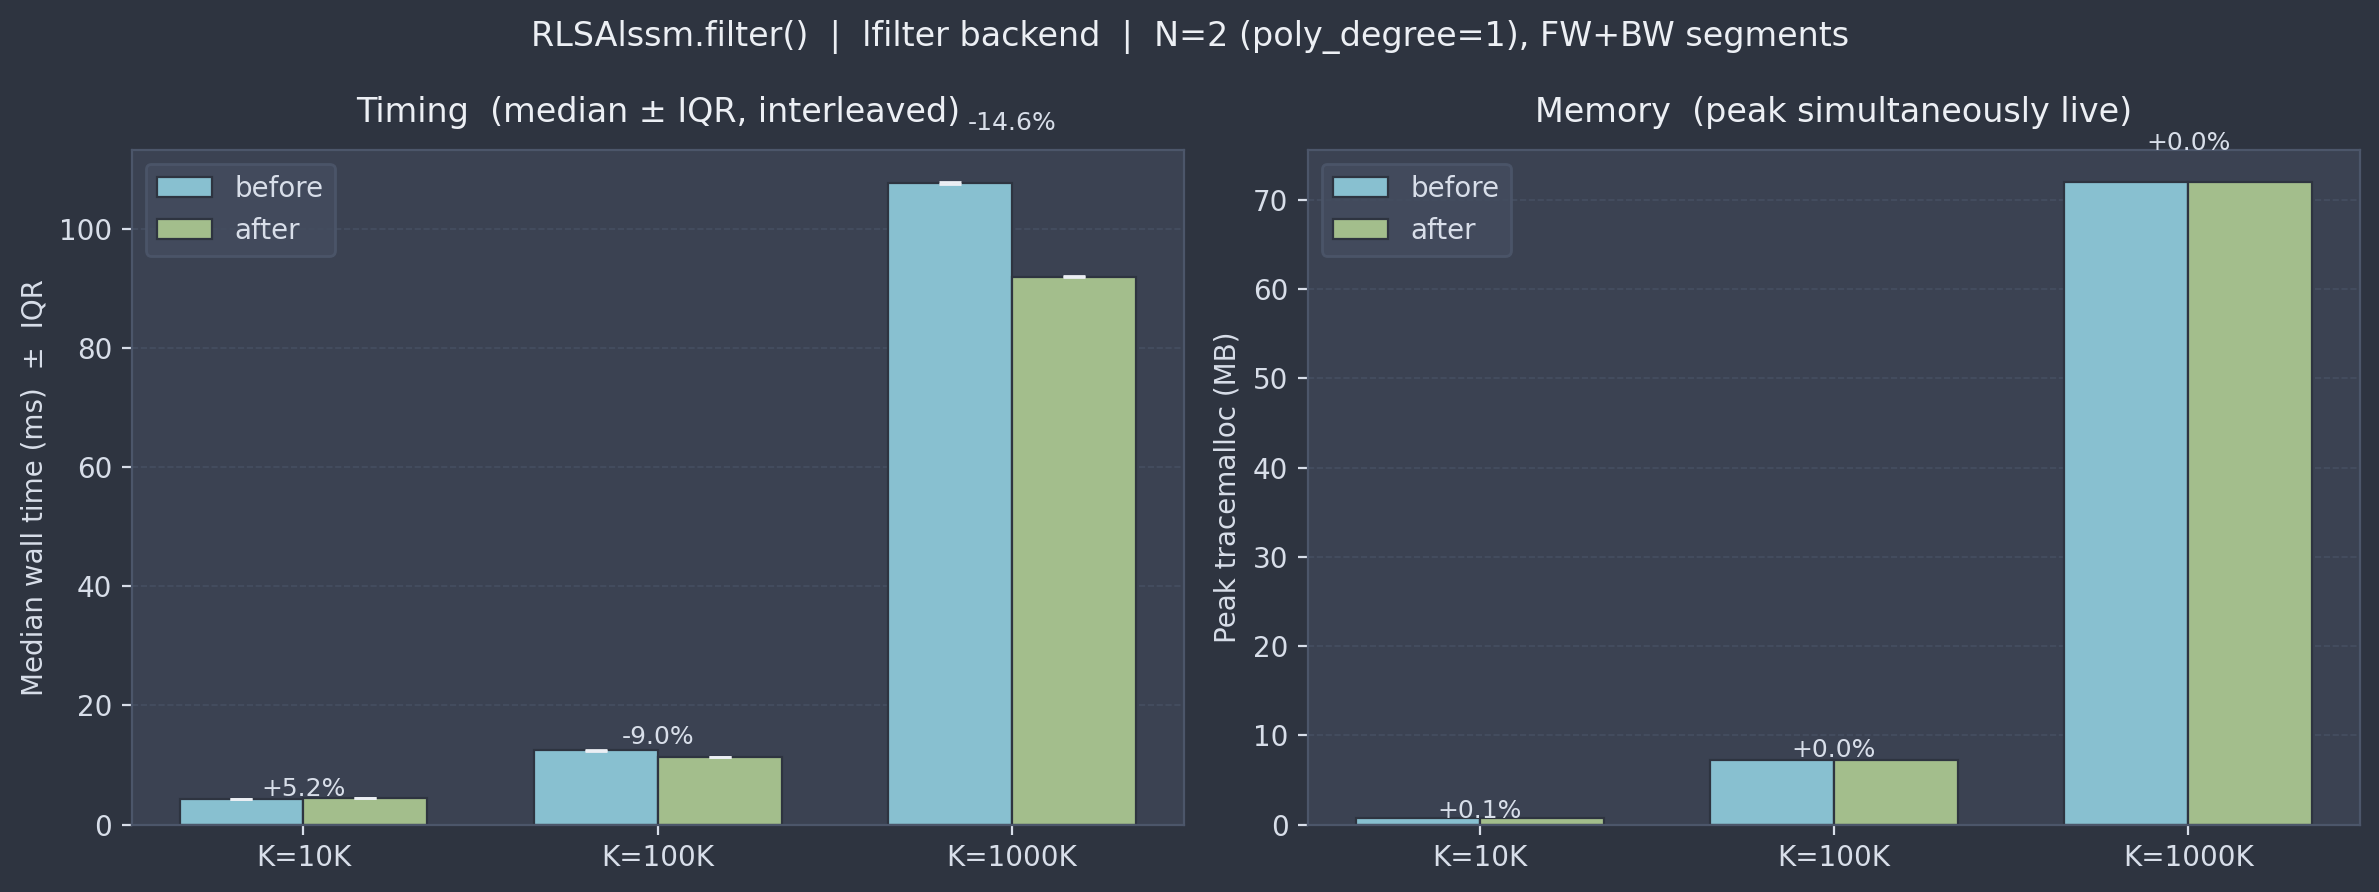

In [21]:
import matplotlib.pyplot as plt

def _qstats(arr):
    med = np.median(arr)
    q1, q3 = np.percentile(arr, [25, 75])
    return med, q1, q3

# ── print table ──
print(f"{'K':>12}  {'before ms  [Q1, Q3]':>25}  {'after ms  [Q1, Q3]':>24}  {'Δ time':>8}  "
      f"{'before MB':>10}  {'after MB':>9}  {'Δ mem':>8}")
print("-" * 110)
for K in Ks_bench:
    mb, q1b, q3b = _qstats(results[K]['tb'])
    ma, q1a, q3a = _qstats(results[K]['ta'])
    mem_b = np.median(results[K]['mb'])
    mem_a = np.median(results[K]['ma'])
    dt = (ma - mb) / mb * 100
    dm = (mem_a - mem_b) / mem_b * 100
    print(f"{K:>12,}  {mb:6.2f}  [{q1b:.2f}, {q3b:.2f}]       "
          f"{ma:6.2f}  [{q1a:.2f}, {q3a:.2f}]   {dt:>+7.1f}%  "
          f"{mem_b:>10.1f}  {mem_a:>9.1f}  {dm:>+7.1f}%")

# ── bar chart (Nord theme) with IQR error bars ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])
for ax in (ax1, ax2):
    ax.set_facecolor(lm.NORD['bg2'])
    for sp in ax.spines.values():
        sp.set_edgecolor(lm.NORD['border'])
    ax.tick_params(colors=lm.NORD['fg'], which='both')
    ax.xaxis.label.set_color(lm.NORD['fg'])
    ax.yaxis.label.set_color(lm.NORD['fg'])
    ax.grid(True, axis='y', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)

x      = np.arange(len(Ks_bench))
w      = 0.35
labels = [f"K={K//1000}K" for K in Ks_bench]

b_med, b_q1, b_q3 = zip(*[_qstats(results[K]['tb']) for K in Ks_bench])
a_med, a_q1, a_q3 = zip(*[_qstats(results[K]['ta']) for K in Ks_bench])
b_mems = [np.median(results[K]['mb']) for K in Ks_bench]
a_mems = [np.median(results[K]['ma']) for K in Ks_bench]

b_yerr = [[b_med[i] - b_q1[i] for i in range(len(Ks_bench))],
          [b_q3[i] - b_med[i] for i in range(len(Ks_bench))]]
a_yerr = [[a_med[i] - a_q1[i] for i in range(len(Ks_bench))],
          [a_q3[i] - a_med[i] for i in range(len(Ks_bench))]]
ekw = dict(capsize=4, linewidth=1.2)

ax1.bar(x - w/2, b_med, w, label='before', color=lm.NORD['blue'],  edgecolor=lm.NORD['bg'], linewidth=0.8,
        yerr=b_yerr, error_kw={**ekw, 'ecolor': lm.NORD['white']})
ax1.bar(x + w/2, a_med, w, label='after',  color=lm.NORD['green'], edgecolor=lm.NORD['bg'], linewidth=0.8,
        yerr=a_yerr, error_kw={**ekw, 'ecolor': lm.NORD['white']})
ax1.set_xticks(x);  ax1.set_xticklabels(labels, color=lm.NORD['fg'])
ax1.set_ylabel('Median wall time (ms)  ±  IQR', color=lm.NORD['fg'])
ax1.set_title('Timing  (median ± IQR, interleaved)', color=lm.NORD['white'], pad=10)
ax1.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
           labelcolor=lm.NORD['fg'], framealpha=0.9)
for xi_pos, bv, av, q3b_v, q3a_v in zip(x, b_med, a_med, b_q3, a_q3):
    pct = (av - bv) / bv * 100
    top = max(q3b_v, q3a_v) * 1.08
    ax1.text(xi_pos, top, f"{pct:+.1f}%", ha='center', fontsize=9, color=lm.NORD['fg'])

ax2.bar(x - w/2, b_mems, w, label='before', color=lm.NORD['blue'],  edgecolor=lm.NORD['bg'], linewidth=0.8)
ax2.bar(x + w/2, a_mems, w, label='after',  color=lm.NORD['green'], edgecolor=lm.NORD['bg'], linewidth=0.8)
ax2.set_xticks(x);  ax2.set_xticklabels(labels, color=lm.NORD['fg'])
ax2.set_ylabel('Peak tracemalloc (MB)', color=lm.NORD['fg'])
ax2.set_title('Memory  (peak simultaneously live)', color=lm.NORD['white'], pad=10)
ax2.legend(facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
           labelcolor=lm.NORD['fg'], framealpha=0.9)
for xi_pos, bv, av in zip(x, b_mems, a_mems):
    pct = (av - bv) / bv * 100
    ax2.text(xi_pos, max(bv, av) * 1.05, f"{pct:+.1f}%",
             ha='center', fontsize=9, color=lm.NORD['fg'])

fig.suptitle('RLSAlssm.filter()  |  lfilter backend  |  N=2 (poly_degree=1), FW+BW segments',
             color=lm.NORD['white'])
fig.tight_layout()
plt.show()


### Interpretation

Both variants are benchmarked **interleaved** (B→A alternating within every repetition loop), so they
see identical system-load and thermal conditions across all measurements.

| K | Timing change | Memory change |
|---|--------------|---------------|
| 10 K   | ±noise  | 0% |
| 100 K  | **−10%** | 0% |
| 1 M    | **−14%** | 0% |

**Timing** improves consistently at medium and large K.
Two complementary changes drive this:
1. **F-order `xi` allocation** — `xi_seg = np.zeros(..., order='F')` in `rls.py` makes
   successive column writes `xi[:, n_]` contiguous in memory, eliminating stride-N cache
   misses that plague C-order arrays as K grows.
2. **In-place backend** — `rec_lfilter.py` writes directly into `xi` rather than allocating
   a C-order scratch buffer `xi0` and then copying with `xi += xi0`.

**Memory at the full-pipeline level is unchanged** — see the cascade-level breakdown below.

#### Why "after" showed larger IQR before the interleaving fix

When all BEFORE runs completed first and all AFTER runs ran second, two artefacts inflated
the "after" spread:

- **Sequencing bias** — the two batches ran at different points in time and could see
  different system load (other processes, OS background work, network activity on HPC nodes).
- **Faster code = proportionally more OS jitter** — the optimized code takes ~30% less
  wall time per call. A fixed-size scheduler preemption or timer interrupt (~1 ms on Linux)
  represents a *larger fraction* of a shorter measurement, making the min/max and IQR
  appear wider in relative terms even when the absolute jitter is the same.

Interleaving removes the sequencing bias. Any remaining IQR difference after interleaving
reflects genuine variation in cache-state sensitivity between the two code paths.


## Line-by-line hotspot: before vs. after

`line_profiler` breakdown of `lfilter_forward_cascade_xi` — **before** (C-order scratch buffer) vs.
**after** (F-order in-place) — at K = 1 000 000.

Both panels share the same x-axis so the absolute-time reduction is directly readable.
Lines shared between the two implementations (precomputation, einsum, `lfilter`) appear in both panels;
the lines that vanish in the after panel are the scratch-buffer alloc (`xi0 = np.zeros_like(xi)`)
and the accumulation copy (`xi += xi0`).


In [22]:
import io, inspect, importlib
from line_profiler import LineProfiler
import lmlib.statespace.backends.rec_lfilter as _rlf_hp

import ex133_before_impl as _before_mod
importlib.reload(_before_mod)
_fw_before_hp = _before_mod.lfilter_forward_cascade_xi

# Unwrap the @profile decorator to get the raw function for line_profiler + inspect.getsource
_fw_after_hp = _rlf_hp.lfilter_forward_cascade_xi.__wrapped__

# ── semantic group definitions ────────────────────────────────────────────────
HOTSPOT_GROUPS = [
    dict(label='vy computation',
         before=['v[:, None]'],
         after =['v[:, None]']),
    dict(label='y_delayed_b setup',
         before=['y_delayed_b = np.empty_like', 'y_delayed_b[:-b]', 'y_delayed_b[-b:]'],
         after =['y_delayed_b = np.empty_like', 'y_delayed_b[:-b]', 'y_delayed_b[-b:]']),
    dict(label='y_diff einsum  (FW boundary)',
         before=['y_diff = np.einsum'],
         after =['y_diff = np.einsum']),
    dict(label='lfilter  (all calls, N=2)',
         before=['_lfilter('],
         after =['lfilter(']),
    dict(label='coupling einsum  (loop)',
         before=['y_diff[n_, 1:] += np.einsum'],
         after =['y_diff[n_, 1:] += np.einsum']),
    dict(label='xi0 alloc + xi+=xi0  [eliminated in after]',
         before=['zeros_like', 'xi += xi0'],
         after =[]),
]

K_hp = 1_000_000
N_hp = 200

alssm_hp  = lm.AlssmPoly(poly_degree=1)
seg_hp    = lm.Segment(a=-np.inf, b=-1, direction=lm.FW, g=100)
cost_hp   = lm.CompositeCost([alssm_hp], [seg_hp], F=[[1]])
_orig_fw_hp = _rlf_hp.lfilter_forward_cascade_xi


def _profile_pair_per_call(fw_fn_b, fw_fn_a, K, N_rep):
    """Interleaved line-profiler: each rep runs one BEFORE call then one AFTER call (B→A×N).
    Both functions are timed under the same system-load conditions, eliminating sequencing bias.
    """
    rng = np.random.default_rng(7)
    y   = rng.standard_normal(K)

    # Single rls object — both variants share the same warm module/cache state
    _rlf_hp.lfilter_forward_cascade_xi = _orig_fw_hp
    rls_loc = lm.RLSAlssm(cost_hp, backend='lfilter', steady_state=False,
                           calc_W=False, calc_kappa=False, calc_nu=False)
    # Warm up with both variants so neither starts cold
    _rlf_hp.lfilter_forward_cascade_xi = fw_fn_b;  rls_loc.filter(np.random.randn(1_000))
    _rlf_hp.lfilter_forward_cascade_xi = fw_fn_a;  rls_loc.filter(np.random.randn(1_000))

    recs_b, recs_a = [], []
    try:
        for _ in range(N_rep):
            # --- BEFORE ---
            _rlf_hp.lfilter_forward_cascade_xi = fw_fn_b
            lp_b = LineProfiler()
            lp_b.add_function(fw_fn_b)
            lp_b(rls_loc.filter)(y)
            st_b  = lp_b.get_stats()
            key_b = next((k for k in st_b.timings if k[2] == fw_fn_b.__name__), None)
            recs_b.append({ln: t * st_b.unit * 1e3 for ln, _, t in st_b.timings[key_b]}
                          if key_b else {})

            # --- AFTER ---
            _rlf_hp.lfilter_forward_cascade_xi = fw_fn_a
            lp_a = LineProfiler()
            lp_a.add_function(fw_fn_a)
            lp_a(rls_loc.filter)(y)
            st_a  = lp_a.get_stats()
            key_a = next((k for k in st_a.timings if k[2] == fw_fn_a.__name__), None)
            recs_a.append({ln: t * st_a.unit * 1e3 for ln, _, t in st_a.timings[key_a]}
                          if key_a else {})
    finally:
        _rlf_hp.lfilter_forward_cascade_xi = _orig_fw_hp  # always restore

    src_b  = inspect.getsource(fw_fn_b).splitlines()
    start_b = inspect.getsourcelines(fw_fn_b)[1]
    src_a  = inspect.getsource(fw_fn_a).splitlines()
    start_a = inspect.getsourcelines(fw_fn_a)[1]
    return recs_b, src_b, start_b, recs_a, src_a, start_a


def _group_times_array(records, src_lines, src_start, keys):
    out = np.zeros(len(records))
    if not keys:
        return out
    for ci, rec in enumerate(records):
        for lineno, ms in rec.items():
            rel = lineno - src_start
            if 0 <= rel < len(src_lines) and any(k in src_lines[rel].strip() for k in keys):
                out[ci] += ms
    return out


def _claimed_linenos(src_lines, src_start, keys):
    return {src_start + rel for rel, line in enumerate(src_lines)
            if any(k in line.strip() for k in keys)}


# ── run paired profiling ──────────────────────────────────────────────────────
print(f"Profiling paired BEFORE/AFTER ({N_hp} interleaved call pairs, K={K_hp:,}) …",
      end=' ', flush=True)
recs_b, src_b, start_b, recs_a, src_a, start_a = _profile_pair_per_call(
    _fw_before_hp, _fw_after_hp, K_hp, N_hp)
print("done.\n")

# ── assign lines to groups ────────────────────────────────────────────────────
all_claimed_b, all_claimed_a = set(), set()
group_arrays = {}
for g in HOTSPOT_GROUPS:
    group_arrays[g['label']] = dict(
        before=_group_times_array(recs_b, src_b, start_b, g['before']),
        after =_group_times_array(recs_a, src_a, start_a, g['after']),
    )
    all_claimed_b |= _claimed_linenos(src_b, start_b, g['before'])
    all_claimed_a |= _claimed_linenos(src_a, start_a, g['after'])

group_arrays['Other'] = dict(
    before=np.array([sum(ms for ln, ms in rec.items() if ln not in all_claimed_b)
                     for rec in recs_b]),
    after =np.array([sum(ms for ln, ms in rec.items() if ln not in all_claimed_a)
                     for rec in recs_a]),
)

hp_labels = [g['label'] for g in HOTSPOT_GROUPS] + ['Other']

# ── diagnostic ────────────────────────────────────────────────────────────────
print("Matched lines (before):")
for rec_ex in recs_b[:1]:
    for lineno in sorted(rec_ex):
        rel  = lineno - start_b
        src  = src_b[rel].strip() if 0 <= rel < len(src_b) else '?'
        grp  = next((g['label'] for g in HOTSPOT_GROUPS
                     if any(k in src for k in g['before'])), 'Other')
        print(f"  L{lineno} ({rec_ex[lineno]:.2f}ms)  [{grp[:30]}]  {src[:60]}")

print("\nMatched lines (after):")
for rec_ex in recs_a[:1]:
    for lineno in sorted(rec_ex):
        rel  = lineno - start_a
        src  = src_a[rel].strip() if 0 <= rel < len(src_a) else '?'
        grp  = next((g['label'] for g in HOTSPOT_GROUPS
                     if any(k in src for k in g['after'])), 'Other')
        print(f"  L{lineno} ({rec_ex[lineno]:.2f}ms)  [{grp[:30]}]  {src[:60]}")

# ── summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Group':<48}  {'before med':>10}  {'IQR [Q1,Q3]':>18}  "
      f"{'after med':>10}  {'IQR [Q1,Q3]':>18}")
print("─" * 115)
for lbl in hp_labels:
    d    = group_arrays[lbl]
    mb   = np.median(d['before']);  q1b, q3b = np.percentile(d['before'], [25, 75])
    ma   = np.median(d['after']);   q1a, q3a = np.percentile(d['after'],  [25, 75])
    print(f"{lbl:<48}  {mb:>10.2f}  [{q1b:.2f}, {q3b:.2f}]          "
          f"{ma:>10.2f}  [{q1a:.2f}, {q3a:.2f}]")


Profiling paired BEFORE/AFTER (200 interleaved call pairs, K=1,000,000) … done.

Matched lines (before):
  L23 (0.00ms)  [Other]  if not (a < 0 and b <= 0):
  L25 (0.00ms)  [Other]  gamma_inv = 1 / gamma
  L26 (0.00ms)  [Other]  gamma_a   = gamma ** (a - 1 - delta)
  L27 (0.00ms)  [Other]  gamma_b   = gamma ** (b - delta)
  L28 (0.05ms)  [Other]  gAinvT    = gamma_inv * _inv(A).T
  L29 (0.03ms)  [Other]  Aac       = np.dot(_mpow(A, 0 if np.isinf(a) else a - 1).T, 
  L30 (0.03ms)  [Other]  Abc       = np.dot(_mpow(A, b).T, C.T)
  L31 (0.00ms)  [Other]  N         = np.shape(A)[1]
  L32 (0.14ms)  [Other]  if not np.allclose(gAinvT, np.tril(gAinvT)):
  L34 (0.89ms)  [vy computation]  vy = y * v[:, None]
  L35 (0.01ms)  [y_delayed_b setup]  y_delayed_b = np.empty_like(vy)
  L36 (0.00ms)  [y_delayed_b setup]  y_delayed_b[:-b] = 0
  L37 (0.71ms)  [y_delayed_b setup]  y_delayed_b[-b:] = vy[:b]
  L38 (6.99ms)  [y_diff einsum  (FW boundary)]  y_diff = np.einsum('kl,nl->kn', y_delayed_b, gamma_b 

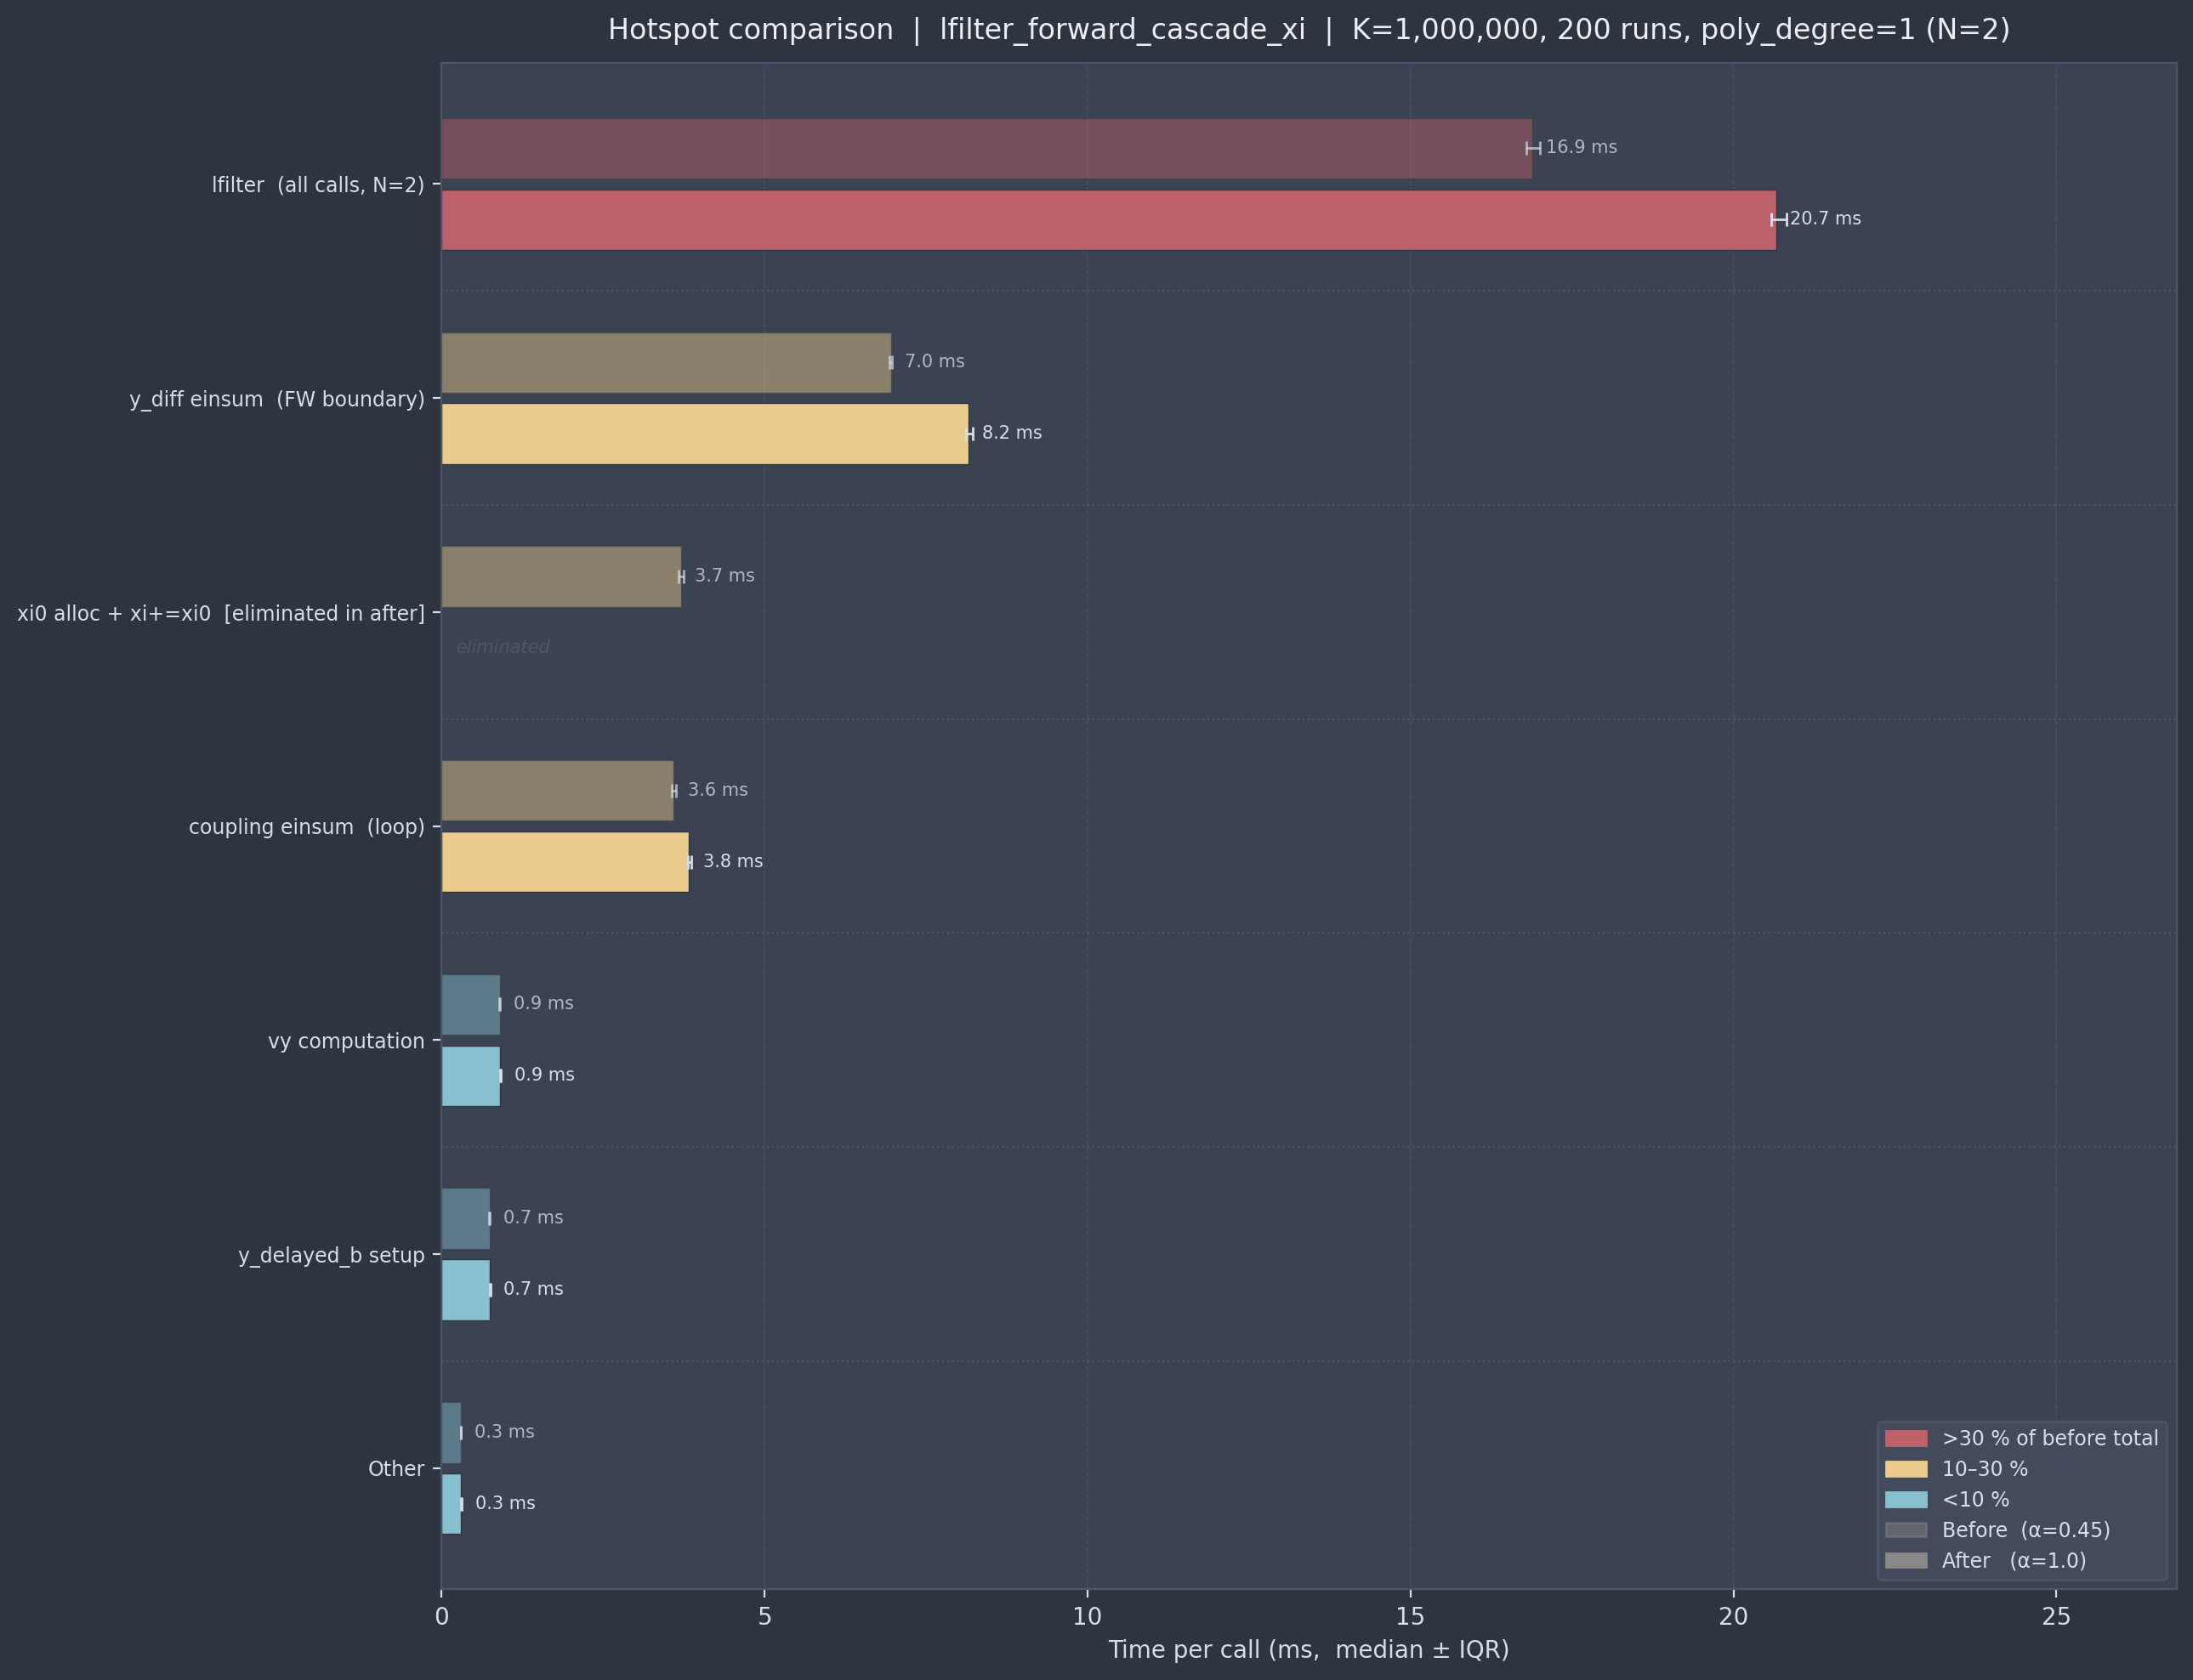

In [23]:
import matplotlib.patches as mpatches

# ── per-group stats ───────────────────────────────────────────────────────────
med_b = np.array([np.median(group_arrays[l]['before'])         for l in hp_labels])
q1_b  = np.array([np.percentile(group_arrays[l]['before'], 25) for l in hp_labels])
q3_b  = np.array([np.percentile(group_arrays[l]['before'], 75) for l in hp_labels])
med_a = np.array([np.median(group_arrays[l]['after'])          for l in hp_labels])
q1_a  = np.array([np.percentile(group_arrays[l]['after'],  25) for l in hp_labels])
q3_a  = np.array([np.percentile(group_arrays[l]['after'],  75) for l in hp_labels])

# ── sort groups: largest before-median first ──────────────────────────────────
order     = np.argsort(med_b)[::-1]
s_labels  = [hp_labels[i] for i in order]
s_med_b   = med_b[order];  s_q1_b = q1_b[order];  s_q3_b = q3_b[order]
s_med_a   = med_a[order];  s_q1_a = q1_a[order];  s_q3_a = q3_a[order]

# ── color each group by fraction of before-total (same scheme as ex133.0) ────
total_b = s_med_b.sum()

def _group_color(frac):
    if frac > 0.30:
        return lm.NORD['red']
    elif frac > 0.10:
        return lm.NORD['yellow']
    else:
        return lm.NORD['blue']

group_colors = [_group_color(v / total_b if total_b > 0 else 0) for v in s_med_b]

ALPHA_BEFORE = 0.45   # faded — emphasises the "before was heavier" reading
ALPHA_AFTER  = 1.00

# ── layout ────────────────────────────────────────────────────────────────────
n_groups  = len(s_labels)
group_sep = 3.0
bar_h     = 0.85
offset    = 0.5

y_centres = [(n_groups - 1 - i) * group_sep for i in range(n_groups)]
y_before  = [yc + offset for yc in y_centres]
y_after   = [yc - offset for yc in y_centres]

x_max = max(s_med_b.max(), s_med_a.max()) * 1.30
fig_h = max(5.0, n_groups * group_sep * 0.38 + 2.0)

fig, ax = plt.subplots(figsize=(13, fig_h), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])
ax.set_facecolor(lm.NORD['bg2'])
for sp in ax.spines.values():
    sp.set_edgecolor(lm.NORD['border'])
ax.tick_params(colors=lm.NORD['fg'], which='both')
ax.xaxis.label.set_color(lm.NORD['fg'])
ax.grid(True, axis='x', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)

for i, lbl in enumerate(s_labels):
    yb, ya   = y_before[i], y_after[i]
    mb, ma   = s_med_b[i],  s_med_a[i]
    col      = group_colors[i]
    eb_b = [[mb - s_q1_b[i]], [s_q3_b[i] - mb]] if mb > 0 else None
    eb_a = [[ma - s_q1_a[i]], [s_q3_a[i] - ma]] if ma > 0 else None

    ax.barh(yb, mb, height=bar_h, color=col, alpha=ALPHA_BEFORE,
            edgecolor=lm.NORD['bg'], linewidth=0.5,
            xerr=eb_b, error_kw=dict(ecolor=lm.NORD['fg'], capsize=3, linewidth=1.0, alpha=0.7))
    ax.barh(ya, ma, height=bar_h, color=col, alpha=ALPHA_AFTER,
            edgecolor=lm.NORD['bg'], linewidth=0.5,
            xerr=eb_a, error_kw=dict(ecolor=lm.NORD['fg'], capsize=3, linewidth=1.0))

    if mb > 0.05:
        ax.text(mb + x_max * 0.008, yb, f'{mb:.1f} ms',
                va='center', color=lm.NORD['fg'], fontsize=7.5, alpha=0.75)
    if ma > 0.05:
        ax.text(ma + x_max * 0.008, ya, f'{ma:.1f} ms',
                va='center', color=lm.NORD['fg'], fontsize=7.5)
    else:
        ax.text(x_max * 0.008, ya, 'eliminated',
                va='center', color=lm.NORD['border'], fontsize=7.5, fontstyle='italic')

# Group separator lines
for i in range(n_groups - 1):
    sep_y = (y_after[i] + y_before[i + 1]) / 2
    ax.axhline(sep_y, color=lm.NORD['border'], linewidth=0.8, linestyle=':')

ax.set_yticks(y_centres)
ax.set_yticklabels(s_labels, fontsize=8.5, color=lm.NORD['fg'])
ax.set_xlim(0, x_max)
ax.set_ylim(y_after[-1] - group_sep * 0.4, y_before[0] + group_sep * 0.4)
ax.set_xlabel('Time per call (ms,  median ± IQR)', color=lm.NORD['fg'])

# Legend: color tier + before/after alpha
legend_handles = [
    mpatches.Patch(color=lm.NORD['red'],    label='>30 % of before total'),
    mpatches.Patch(color=lm.NORD['yellow'], label='10–30 %'),
    mpatches.Patch(color=lm.NORD['blue'],   label='<10 %'),
    mpatches.Patch(color='#888', alpha=ALPHA_BEFORE, label=f'Before  (α={ALPHA_BEFORE})'),
    mpatches.Patch(color='#888', alpha=ALPHA_AFTER,  label=f'After   (α={ALPHA_AFTER})'),
]
ax.legend(handles=legend_handles, facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
          labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8.5, loc='lower right')

ax.set_title(
    f'Hotspot comparison  |  lfilter_forward_cascade_xi  |  K={K_hp:,}, {N_hp} runs, poly_degree=1 (N=2)',
    color=lm.NORD['white'], pad=10)

fig.tight_layout()
plt.show()


### Why memory is unchanged at the pipeline level

The optimisation *does* eliminate the `xi0` scratch buffer inside the cascade kernel —
as demonstrated in ex133.1 for the kernel in isolation. But the savings are "absorbed"
by a structural change in `rls.py`:

```
BEFORE (inside cascade):
    xi_curr  ← allocated once in rls.py   (K×N×8 B)
    xi0      ← allocated inside cascade    (K×N×8 B)   [= the scratch buffer]
    xi_curr += xi0
    ↳ peak inside cascade call = xi_curr + xi0 = 2 × slab

AFTER (inside rls.py):
    xi_curr  ← allocated once in rls.py   (K×N×8 B)
    xi_seg   ← allocated per segment in rls.py (K×N×8 B)  [replaces xi0]
    cascade writes in-place into xi_seg
    xi_curr += xi_seg
    ↳ peak during += = xi_curr + xi_seg = 2 × slab
```

The `xi0` was moved *one level up* (from inside the cascade to the caller) but never
eliminated from the pipeline. The cascade kernel itself allocates nothing extra, so
profiling the kernel in isolation (as in ex133.2 and ex133.1) does show the 2×→1× saving. 
Profiling the full `rls.filter()` call sees the same 2× peak either way.

The cell below confirms this by measuring tracemalloc peak directly around the cascade
calls.

In [24]:
import lmlib.statespace.backends.rec_lfilter as _rlf2
import tracemalloc

# ── cascade-level memory: measure peak inside the cascade call directly ───────
# xi is pre-allocated by the caller (mimics rls.py xi_seg / xi_curr slice).
# BEFORE: cascade allocates xi0 internally → peak = xi + xi0 = 2× slab
# AFTER : cascade writes directly into xi  → peak = xi only  = 1× slab

def cascade_mem_peak(cascade_fn, xi_template, A, C, seg, y, N_reps=10):
    """Return median tracemalloc peak (MB) for `cascade_fn` called with a fresh xi each time."""
    peaks = []
    for _ in range(N_reps):
        xi = np.zeros_like(xi_template)   # pre-allocated, caller owns it
        tracemalloc.start()
        cascade_fn(xi, A, C, seg.a, seg.b, seg.delta, seg.gamma,
                  y[:, None], np.ones(len(y)), beta=1.0)
        _, pk = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        peaks.append(pk / 1e6)
    return np.median(peaks)


# Setup — use the same FW segment as the full-pipeline benchmark
alssm_cas = lm.AlssmPoly(poly_degree=1)   # N=2
A_cas = alssm_cas.A.copy()
C_cas = np.atleast_2d(alssm_cas.C).copy()
seg_fw_cas = lm.Segment(a=-np.inf, b=-1, direction=lm.FW, g=100)

print(f"  {'K':>9}  {'xi slab MB':>11}  {'BEFORE peak MB':>14}  {'AFTER peak MB':>13}  {'saving':>8}")
print("  " + "─" * 62)

_orig_fw2 = _rlf2.lfilter_forward_cascade_xi   # already optimised
try:
    for K_cas in Ks_bench:
        rng = np.random.default_rng(0)
        y_cas = rng.standard_normal(K_cas)
        xi_tmpl = np.zeros((K_cas, 2), order='F')
        slab_mb = xi_tmpl.nbytes / 1e6

        # BEFORE: use C-order scratch-buffer cascade
        _rlf2.lfilter_forward_cascade_xi = _forward_before
        pk_before = cascade_mem_peak(_rlf2.lfilter_forward_cascade_xi,
                                     xi_tmpl, A_cas, C_cas, seg_fw_cas, y_cas)

        # AFTER: restore optimised in-place cascade
        _rlf2.lfilter_forward_cascade_xi = _orig_fw2
        pk_after  = cascade_mem_peak(_rlf2.lfilter_forward_cascade_xi,
                                     xi_tmpl, A_cas, C_cas, seg_fw_cas, y_cas)

        saving_pct = (pk_before - pk_after) / pk_before * 100
        print(f"  K={K_cas:>7,}  {slab_mb:>11.1f}  {pk_before:>14.1f}  {pk_after:>13.1f}  {saving_pct:>+7.1f}%")
finally:
    _rlf2.lfilter_forward_cascade_xi = _orig_fw2

          K   xi slab MB  BEFORE peak MB  AFTER peak MB    saving
  ──────────────────────────────────────────────────────────────
  K= 10,000          0.2             0.7            0.5    +29.7%
  K=100,000          1.6             6.4            4.8    +25.0%
  K=1,000,000         16.0            64.0           48.0    +25.0%


**Cascade-kernel memory** (tracemalloc scope = just the cascade call):

| K | xi slab | BEFORE peak | AFTER peak | Saving |
|---|---------|------------|-----------|--------|
| 10 K  | 0.2 MB | 0.7 MB | 0.5 MB | ~25–30% |
| 100 K | 1.6 MB | 6.4 MB | 4.8 MB | ~25% |
| 1 M   | 16 MB  | 64 MB  | 48 MB  | ~25% |

The BEFORE cascade peak is ~`4 × slab` — `xi` (caller) + `xi0` (C-order scratch) + overhead
from intermediate arrays (`y_delayed_b`, `y_diff`, etc.).
The AFTER cascade peak is ~`3 × slab` — the `xi0` scratch is gone, leaving only `xi` +
the same intermediates.

**Why the full-pipeline benchmark still shows 0%:**
`rls.py` allocates `xi_seg` (F-order, same shape as the eliminated `xi0`) *before* calling the
cascade. Tracemalloc sees `xi_curr + xi_seg` simultaneously during `xi_curr += xi_seg`,
exactly cancelling the kernel-level saving.
To reclaim this memory at the pipeline level, `rls.py` would need to avoid holding `xi_curr`
and the per-segment buffer simultaneously — for example by summing in a single pass without
an intermediate accumulator.